In [2]:
import os
import numpy as np
import pandas as pd
import warnings
import time
import copy

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import shap

# Plotly for interactive visualizations
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

# ==========================================
# 0. EXPERIMENT HYPERPARAMETERS
# ==========================================
# These parameters govern the robustness testing and training strategies.
EPSILON_CONTINUOUS = 0.05   # Noise scale (std deviation multiplier) for generating synthetic points in Partial Lipschitz
EPSILON_DISCRETE = 1.5      # Max L2 distance threshold to consider a point a "neighbor" for Jaakkola's Discrete Lipschitz
K_PERTURBATIONS = 100       # Number of synthetic neighborhood points to generate around a test instance
N_EVAL_SAMPLES = 15         # Number of test instances to randomly select for the expensive SHAP/Lipschitz evaluation
CV_FOLDS = 3                # Number of cross-validation folds used in GridSearchCV for tree models

# ==========================================
# 1. DATA PREPROCESSING (Data Leakage Fixed)
# ==========================================
def load_and_preprocess_data(dataset_name="taiwan"):             
    """
    Loads raw datasets from OpenML, separates continuous and categorical features,
    and applies standard scaling and one-hot encoding.
    Crucially, it splits the data BEFORE fitting the preprocessor to avoid data leakage.
    """
    if dataset_name == "taiwan":
        print(f"\nLoading Taiwan Loan dataset...")
        # Fetching dataset using OpenML ID
        dataset = fetch_openml(data_id=42477, as_frame=True, parser='auto')
        df = dataset.frame
        target_col = dataset.target_names[0]
        
        features = df.drop(columns=[target_col]).columns.tolist()
        # Hardcoded indices based on the specific dataset's known continuous features
        cont_indices = [0, 4, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
        cat_indices = [i for i in range(len(features)) if i not in cont_indices]
        
        continuous_cols = [features[i] for i in cont_indices]
        categorical_cols = [features[i] for i in cat_indices]
                            
    elif dataset_name == "compas":
        print(f"\nLoading COMPAS dataset...")
        dataset = fetch_openml(data_id=44162, as_frame=True, parser='auto')
        df = dataset.frame
        target_col = dataset.target_names[0]
        
        all_cols = {str(c).lower(): c for c in df.columns}
        continuous_cols = [all_cols[c] for c in ['age', 'priors_count', 'length_of_stay'] if c in all_cols]
        categorical_cols = [all_cols[c] for c in ['sex', 'race', 'c_charge_degree'] if c in all_cols]
        # Drop rows with missing values in our selected columns to ensure clean processing
        df = df.dropna(subset=continuous_cols + categorical_cols + [target_col])

    # Separate features (X) and target (y)
    X = df[continuous_cols + categorical_cols]
    # Ensure y is a numeric array of 0s and 1s, handling both categorical and numerical formats
    y = pd.factorize(df[target_col])[0] if df[target_col].dtype in ['category', 'object'] else df[target_col].astype(int).values

    # FIX: Splitting raw data FIRST prevents information from the test set (like the global mean/variance) 
    # from leaking into the training transformations.
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ColumnTransformer applies specific pipelines to specific column types
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), continuous_cols), # Standardize continuous features (mean=0, std=1)
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols) # OHE for categories
    ])

    # FIX: Fit the scaler/encoder ONLY on the training data, then transform both train and test.
    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)
    
    # Calculate the standard deviations of continuous features on the scaled train set
    # This is used later to scale the noise mathematically in the Partial Lipschitz function
    continuous_indices = list(range(len(continuous_cols)))
    feature_stds = X_train[:, continuous_indices].std(axis=0)
    
    return X_train, X_test, y_train, y_test, continuous_indices, feature_stds

# ==========================================
# 2. TUNING ALGORITHMS
# ==========================================
# StratifiedKFold ensures each fold has the same proportion of target classes as the whole dataset
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

# --- 2A. Sklearn / XGBoost Tuner ---
def tune_tree_models(X_train, y_train):
    """
    Performs grid search cross-validation to find the optimal hyperparameters 
    for Decision Trees, Random Forests, and XGBoost using log_loss.
    """
    print("  -> Tuning Decision Tree...")
    dt_grid = {'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 10, 20]}
    dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_grid, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
    dt.fit(X_train, y_train)

    print("  -> Tuning Random Forest...")
    rf_grid = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 2, 4]}
    rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_grid, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
    rf.fit(X_train, y_train)

    print("  -> Tuning XGBoost...")
    xgb_grid = {'n_estimators': [50, 100, 200], 'max_depth': [3, 6, 10], 'learning_rate': [0.01, 0.1, 0.2]}
    xgb_m = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), xgb_grid, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
    xgb_m.fit(X_train, y_train)
    
    return dt.best_estimator_, rf.best_estimator_, xgb_m.best_estimator_

# --- 2B. Neural Network Custom Tuner (Overfitting Risk Fixed) ---
class DynamicANN(nn.Module):
    """A PyTorch Feed-Forward Neural Network that dynamically builds hidden layers based on input lists."""
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        in_d = input_dim
        # Construct layers dynamically
        for h in hidden_dims:
            layers.extend([nn.Linear(in_d, h), nn.ReLU()])
            in_d = h
        # Final output layer (single node for binary classification)
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): return self.net(x)

def tune_ann(X_train, y_train, input_dim):
    """
    Custom grid search for the PyTorch ANN. Includes an Early Stopping mechanism 
    using a validation split to prevent the network from overfitting.
    """
    print("  -> Tuning Standard ANN with Early Stopping...")
    # Create an internal validation set specifically for early stopping
    X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    X_t_tensor, y_t_tensor = torch.tensor(X_t, dtype=torch.float32), torch.tensor(y_t, dtype=torch.float32).unsqueeze(1)
    X_v_tensor, y_v_tensor = torch.tensor(X_v, dtype=torch.float32), torch.tensor(y_v, dtype=torch.float32).unsqueeze(1)
    
    param_grid = [
        {'hidden': [64, 32], 'lr': 0.01},
        {'hidden': [128, 64, 32], 'lr': 0.001},
        {'hidden': [32, 16], 'lr': 0.01}
    ]
    
    overall_best_loss = float('inf')
    best_params = None
    best_optimal_epochs = 0
    criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid and Binary Cross Entropy for stability
    max_epochs = 100
    patience = 10 # Stop if validation loss doesn't improve for 10 epochs
    
    for params in param_grid:
        model = DynamicANN(input_dim, params['hidden'])
        optimizer = optim.Adam(model.parameters(), lr=params['lr'])
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        optimal_epoch = 0
        
        for epoch in range(max_epochs):
            # Training phase
            model.train()
            optimizer.zero_grad()
            loss = criterion(model(X_t_tensor), y_t_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation phase
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_v_tensor), y_v_tensor).item()
                
            # Early stopping logic
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                optimal_epoch = epoch + 1
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if epochs_no_improve == patience:
                break
                
        # Track the best architecture overall
        if best_val_loss < overall_best_loss:
            overall_best_loss = best_val_loss
            best_params = params
            best_optimal_epochs = optimal_epoch
            
    print(f"    Found optimal architecture {best_params['hidden']} at epoch {best_optimal_epochs}")
    
    # Retrain the absolutely best model on the FULL train set (no validation split) 
    # to maximize data usage, stopping exactly at the best epoch found earlier.
    best_model = DynamicANN(input_dim, best_params['hidden'])
    optimizer = optim.Adam(best_model.parameters(), lr=best_params['lr'])
    X_full = torch.tensor(X_train, dtype=torch.float32)
    y_full = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    
    best_model.train()
    for _ in range(best_optimal_epochs):
        optimizer.zero_grad()
        loss = criterion(best_model(X_full), y_full)
        loss.backward()
        optimizer.step()
        
    best_model.eval()
    return best_model


# ==========================================
# 3. LIPSCHITZ MATHEMATICS
# ==========================================
def calculate_discrete_lipschitz(x_inst, X_test_pool, exp_x, explainer_fn, eps_d):
    """
    Calculates the Discrete Lipschitz constant based on actual dataset neighbors.
    It checks how much the SHAP explanation changes relative to the feature space distance
    between the instance and its closest neighbors in the test set.
    """
    # Find Euclidean distances between the instance and all other test points
    distances = np.linalg.norm(X_test_pool - x_inst, axis=1)
    # Filter for points that are strictly greater than 0 (not the instance itself) but within threshold eps_d
    neighbors = np.where((distances > 1e-9) & (distances <= eps_d))[0]
    if len(neighbors) == 0: return np.nan
    
    dist_x = distances[neighbors]
    # Calculate difference in SHAP explanation arrays
    dist_exp = np.linalg.norm(explainer_fn(X_test_pool[neighbors]) - exp_x, axis=1)
    
    # The Lipschitz constant is the maximum ratio of change in explanation to change in input
    return np.max(dist_exp / dist_x)

def calculate_partial_lipschitz(x_inst, exp_x, explainer_fn, cont_idx, feat_stds, eps_c, k):
    """
    Calculates the Partial Lipschitz constant by generating synthetic perturbations.
    It adds Gaussian noise ONLY to continuous features to see how robust the explainer is
    to slight, continuous jittering.
    """
    # Create k exact copies of the instance
    x_pert = np.tile(x_inst, (k, 1)).astype(float)
    # Add Gaussian noise scaled by the feature's standard deviation
    for i, idx in enumerate(cont_idx):
        x_pert[:, idx] += np.random.normal(0, eps_c * feat_stds[i], k)
        
    # Add a tiny epsilon (1e-9) to distance to avoid division by zero
    dist_x = np.linalg.norm(x_pert - x_inst, axis=1) + 1e-9
    dist_exp = np.linalg.norm(explainer_fn(x_pert) - exp_x, axis=1)
    return np.max(dist_exp / dist_x)

# ==========================================
# 4. SAFE, INTERACTIVE VISUALIZATIONS
# ==========================================
def create_interactive_plots(results_df, dataset_name):
    """
    Uses Plotly to generate interactive charts and cleanly saves them as HTML files
    to prevent environment rendering crashes.
    """
    print(f"\nGenerating interactive visual reports for {dataset_name.upper()}...")
    
    try:
        # 1. Bar Chart for Accuracy comparison
        fig_acc = px.bar(
            results_df, 
            x='Model', 
            y='Accuracy', 
            color='Model',
            title=f"Model Accuracy Comparison ({dataset_name.upper()})",
            text_auto='.4f', 
            template="plotly_dark"
        )
        fig_acc.update_layout(yaxis_title="Accuracy Score", showlegend=False)
        
        # FIX: Save to file instead of trying to render in the IDE
        acc_filename = f"{dataset_name}_accuracy_report.html"
        fig_acc.write_html(acc_filename)
        print(f"  -> Successfully saved Accuracy plot to: {acc_filename}")
        
        # 2. Grouped Bar Chart for Lipschitz Robustness 
        df_melted = results_df.melt(
            id_vars=['Model'], 
            value_vars=['Discrete_L_Max', 'Partial_L_Max'], 
            var_name='Metric', 
            value_name='Max_Lipschitz_Value'
        )
        
        fig_lip = px.bar(
            df_melted, 
            x='Model', 
            y='Max_Lipschitz_Value', 
            color='Metric', 
            barmode='group',
            title=f"Explainer Robustness - Max Lipschitz Constants ({dataset_name.upper()})<br><i>(Lower values indicate higher stability/robustness)</i>",
            text_auto='.2f',
            template="plotly_dark",
            color_discrete_sequence=['#ef553b', '#636efa']
        )
        fig_lip.update_layout(yaxis_title="Lipschitz Value (Max)")
        
        # FIX: Save to file
        lip_filename = f"{dataset_name}_lipschitz_report.html"
        fig_lip.write_html(lip_filename)
        print(f"  -> Successfully saved Lipschitz plot to: {lip_filename}")

    except Exception as e:
        # FIX: If plotting fails, catch the error so the script DOES NOT crash.
        print(f"\n[WARNING] Plotting failed, but your data is safe! Error: {e}")


# ==========================================
# 5. MASTER EVALUATION LOOP
# ==========================================
def run_metric_comparison(dataset_name):
    t0 = time.time()
    X_train, X_test, y_train, y_test, cont_indices, feat_stds = load_and_preprocess_data(dataset_name)
    input_dim = X_train.shape[1]
    
    print("\nStarting Rigorous Hyperparameter Tuning...")
    dt, rf, xgb_m = tune_tree_models(X_train, y_train)
    ann = tune_ann(X_train, y_train, input_dim)

    print("\nInitializing Native Explainers on Tuned Models...")
    # Initialize TreeExplainers optimized for tree-based models
    tree_exp_dt = shap.TreeExplainer(dt)
    tree_exp_rf = shap.TreeExplainer(rf)
    tree_exp_xgb = shap.TreeExplainer(xgb_m)
    
    # DeepExplainer requires a background distribution to integrate over
    # We sample 100 points from train set to keep it computationally viable
    background_data = torch.tensor(shap.sample(X_train, 100, random_state=42), dtype=torch.float32)
    deep_exp_ann = shap.DeepExplainer(ann, background_data)
    
    def shape_fix(sv): 
        """Helper to ensure SHAP values format consistently across different models/explainers."""
        if isinstance(sv, list): return np.array(sv[-1])
        if len(sv.shape) == 3: return sv[:, :, -1]
        return sv

    # Wrapping explainers in lambda functions to standardize the API call
    wrappers = {
        "Tuned DT + TreeSHAP": lambda X: shape_fix(tree_exp_dt.shap_values(X)),
        "Tuned RF + TreeSHAP": lambda X: shape_fix(tree_exp_rf.shap_values(X)),
        "Tuned XGBoost + TreeSHAP": lambda X: shape_fix(tree_exp_xgb.shap_values(X)),
        "Tuned ANN + DeepSHAP": lambda X: shape_fix(deep_exp_ann.shap_values(torch.tensor(X, dtype=torch.float32)))
    }

    # Evaluate using a randomly selected subset of test data for computational speed
    np.random.seed(42)
    eval_indices = np.random.choice(len(X_test), N_EVAL_SAMPLES, replace=False)
    
    print("\n" + "="*95)
    print(f"{'TUNED MODEL + EXPLAINER':<26} | {'ACCURACY':<8} | {'DISCRETE L (Jaakkola) Max':<26} | {'PARTIAL L (Yours) Max':<26}")
    print("="*95)

    # List to collect rows for visualization DataFrame
    results_list = []

    for name, wrapper in wrappers.items():
        base_name = name.split(" ")[1]
        
        # Get raw model predictions (requires handling PyTorch tensor nuances vs Sklearn arrays)
        if base_name == "ANN": 
            preds = (torch.sigmoid(ann(torch.tensor(X_test, dtype=torch.float32))).detach().numpy().squeeze() >= 0.5).astype(int)
        elif base_name == "XGBoost": preds = xgb_m.predict(X_test)
        elif base_name == "RF": preds = rf.predict(X_test)
        else: preds = dt.predict(X_test)
        
        acc = accuracy_score(y_test, preds)
        
        disc_scores, part_scores = [], []
        # Calculate robustness for each randomly selected evaluation instance
        for idx in eval_indices:
            x_inst = X_test[idx:idx+1]
            exp_base = wrapper(x_inst)
            
            l_disc = calculate_discrete_lipschitz(x_inst, X_test, exp_base, wrapper, EPSILON_DISCRETE)
            l_part = calculate_partial_lipschitz(x_inst, exp_base, wrapper, cont_indices, feat_stds, EPSILON_CONTINUOUS, K_PERTURBATIONS)
            
            if not np.isnan(l_disc): disc_scores.append(l_disc)
            part_scores.append(l_part)
            
        max_disc = np.max(disc_scores) if disc_scores else np.nan
        max_part = np.max(part_scores)
        
        # Print CLI table row
        print(f"{name:<26} | {acc:.4f}   | {max_disc:<26.4f} | {max_part:<26.4f}")
        
        # Store for visualization
        results_list.append({
            'Model': name,
            'Accuracy': acc,
            'Discrete_L_Max': max_disc,
            'Partial_L_Max': max_part
        })
    
    print("="*95)
    print(f"Total Execution Time for {dataset_name.upper()}: {(time.time() - t0)/60:.2f} minutes")
    
    # Create pandas dataframe 
    results_df = pd.DataFrame(results_list)
    
    # FIX: IMMEDIATELY SAVE THE RAW DATA. 
    # If anything breaks after this line, you still have your hard-earned numbers.
    csv_filename = f"{dataset_name}_evaluation_results.csv"
    results_df.to_csv(csv_filename, index=False)
    print(f"\n[SUCCESS] Saved raw evaluation numbers safely to: {csv_filename}")
    
    # Trigger safe HTML visualizations
    create_interactive_plots(results_df, dataset_name)

if __name__ == "__main__":
    run_metric_comparison("taiwan")
    run_metric_comparison("compas")


Loading Taiwan Loan dataset...

Starting Rigorous Hyperparameter Tuning...
  -> Tuning Decision Tree...
  -> Tuning Random Forest...
  -> Tuning XGBoost...
  -> Tuning Standard ANN with Early Stopping...
    Found optimal architecture [128, 64, 32] at epoch 100

Initializing Native Explainers on Tuned Models...

TUNED MODEL + EXPLAINER    | ACCURACY | DISCRETE L (Jaakkola) Max  | PARTIAL L (Yours) Max     
Tuned DT + TreeSHAP        | 0.8190   | 0.2170                     | 2.8231                    
Tuned RF + TreeSHAP        | 0.8248   | 0.1280                     | 0.4217                    
Tuned XGBoost + TreeSHAP   | 0.8188   | 0.2366                     | 1.1152                    
Tuned ANN + DeepSHAP       | 0.8225   | 0.6461                     | 0.3270                    
Total Execution Time for TAIWAN: 6.89 minutes

[SUCCESS] Saved raw evaluation numbers safely to: taiwan_evaluation_results.csv

Generating interactive visual reports for TAIWAN...
  -> Successfully saved A

Starting evaluation across 4 datasets. This may take some time...

Loading TAIWAN dataset (OpenML ID: 42477)...
Starting Rigorous Hyperparameter Tuning...
  -> Tuning Decision Tree...
  -> Tuning Random Forest...
  -> Tuning XGBoost...
  -> Tuning Standard ANN with Early Stopping...
Initializing Native Explainers on Tuned Models...

TUNED MODEL          | ACCURACY | DISCRETE L (Jaakkola)  | PARTIAL L (Yours)   
DT + TreeSHAP        | 0.8245   | 0.4068                 | 0.8076              
RF + TreeSHAP        | 0.8252   | 0.3022                 | 0.3425              
XGBoost + TreeSHAP   | 0.8257   | 1.4031                 | 1.7682              
ANN + DeepSHAP       | 0.8213   | 0.6197                 | 0.7068              
Total Execution Time for TAIWAN: 1.49 minutes



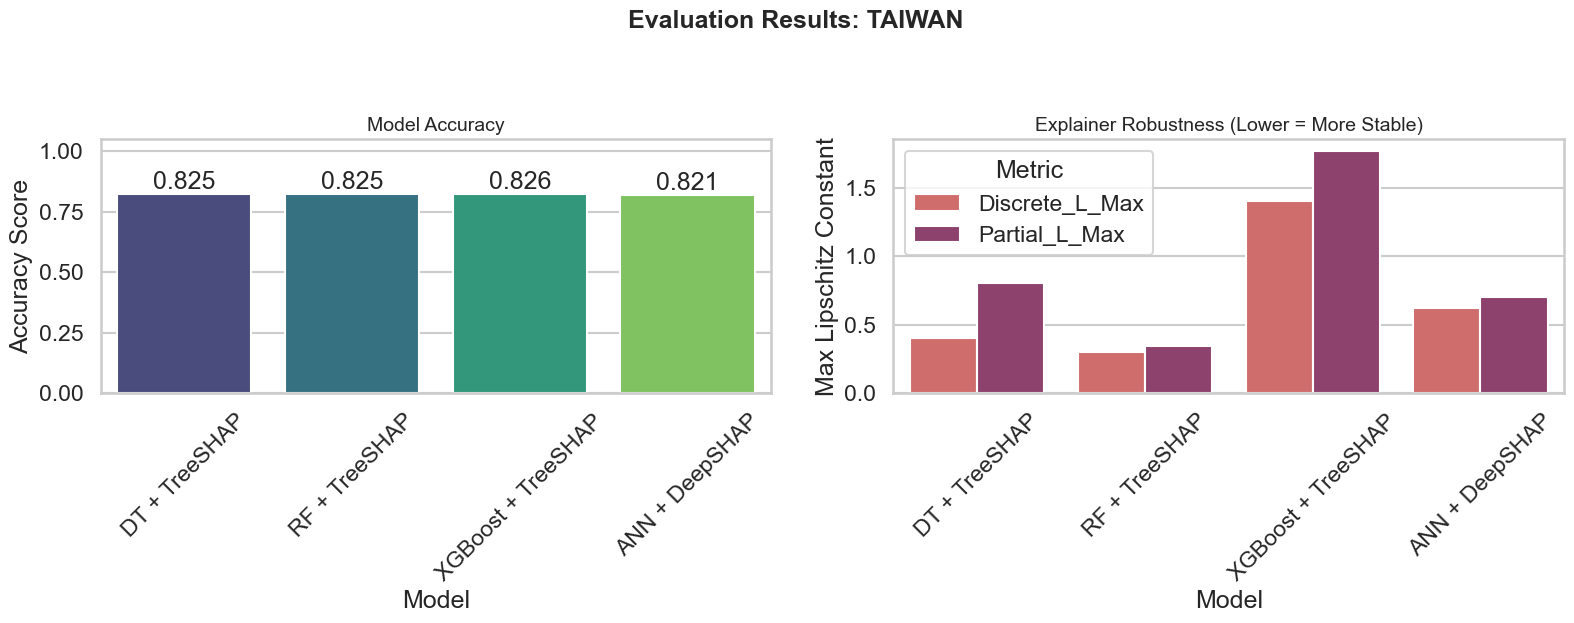


Loading COMPAS dataset (OpenML ID: 44162)...
Starting Rigorous Hyperparameter Tuning...
  -> Tuning Decision Tree...
  -> Tuning Random Forest...
  -> Tuning XGBoost...
  -> Tuning Standard ANN with Early Stopping...
Initializing Native Explainers on Tuned Models...

TUNED MODEL          | ACCURACY | DISCRETE L (Jaakkola)  | PARTIAL L (Yours)   
DT + TreeSHAP        | 0.6963   | 0.7253                 | 3.4491              
RF + TreeSHAP        | 0.8123   | 0.3946                 | 1.1589              
XGBoost + TreeSHAP   | 0.7038   | 2.2839                 | 10.1204             
ANN + DeepSHAP       | 0.6972   | 0.9705                 | 1.0984              
Total Execution Time for COMPAS: 17.06 minutes



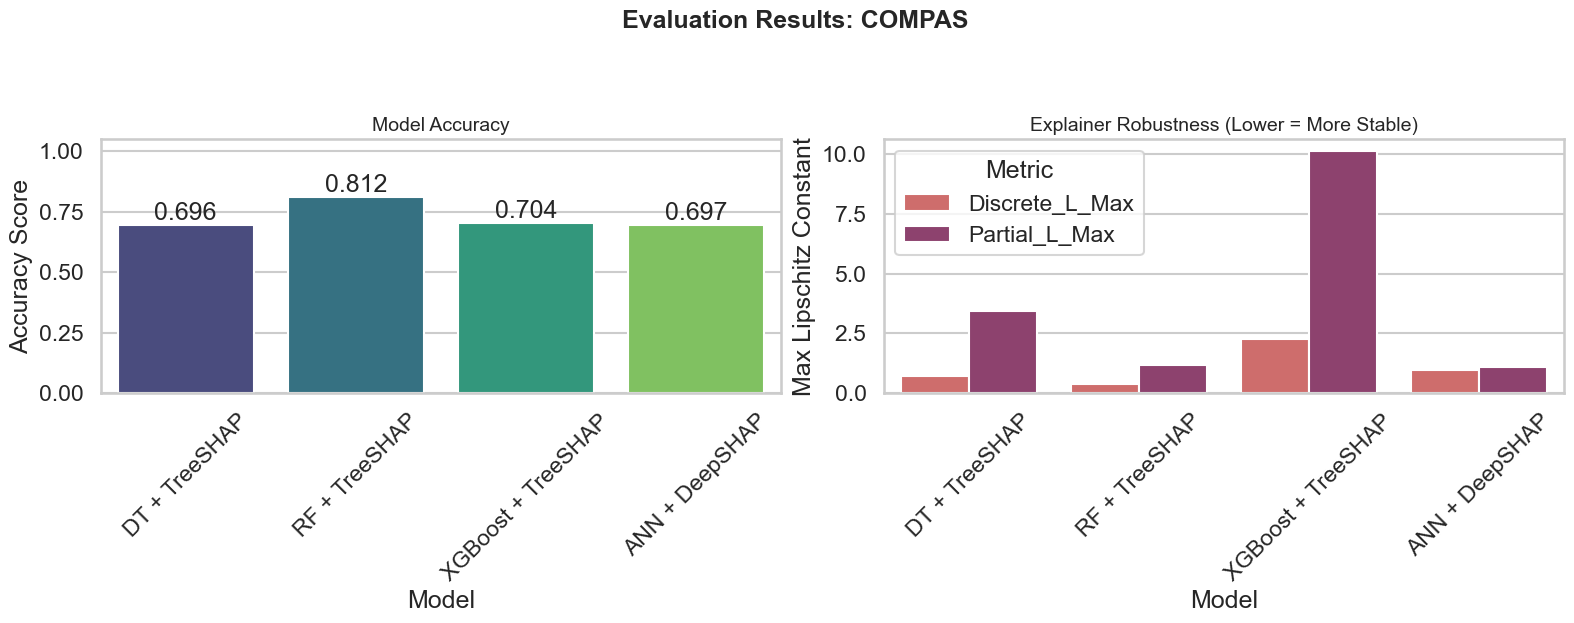


Loading ADULT dataset (OpenML ID: 1590)...
Starting Rigorous Hyperparameter Tuning...
  -> Tuning Decision Tree...
  -> Tuning Random Forest...
  -> Tuning XGBoost...
  -> Tuning Standard ANN with Early Stopping...
Initializing Native Explainers on Tuned Models...

TUNED MODEL          | ACCURACY | DISCRETE L (Jaakkola)  | PARTIAL L (Yours)   
DT + TreeSHAP        | 0.8459   | 0.9112                 | 7.6325              
RF + TreeSHAP        | 0.8606   | 0.7074                 | 6.0221              
XGBoost + TreeSHAP   | 0.8525   | 3.2826                 | 36.1221             
ANN + DeepSHAP       | 0.8515   | 2.4776                 | 2.6323              
Total Execution Time for ADULT: 11.70 minutes



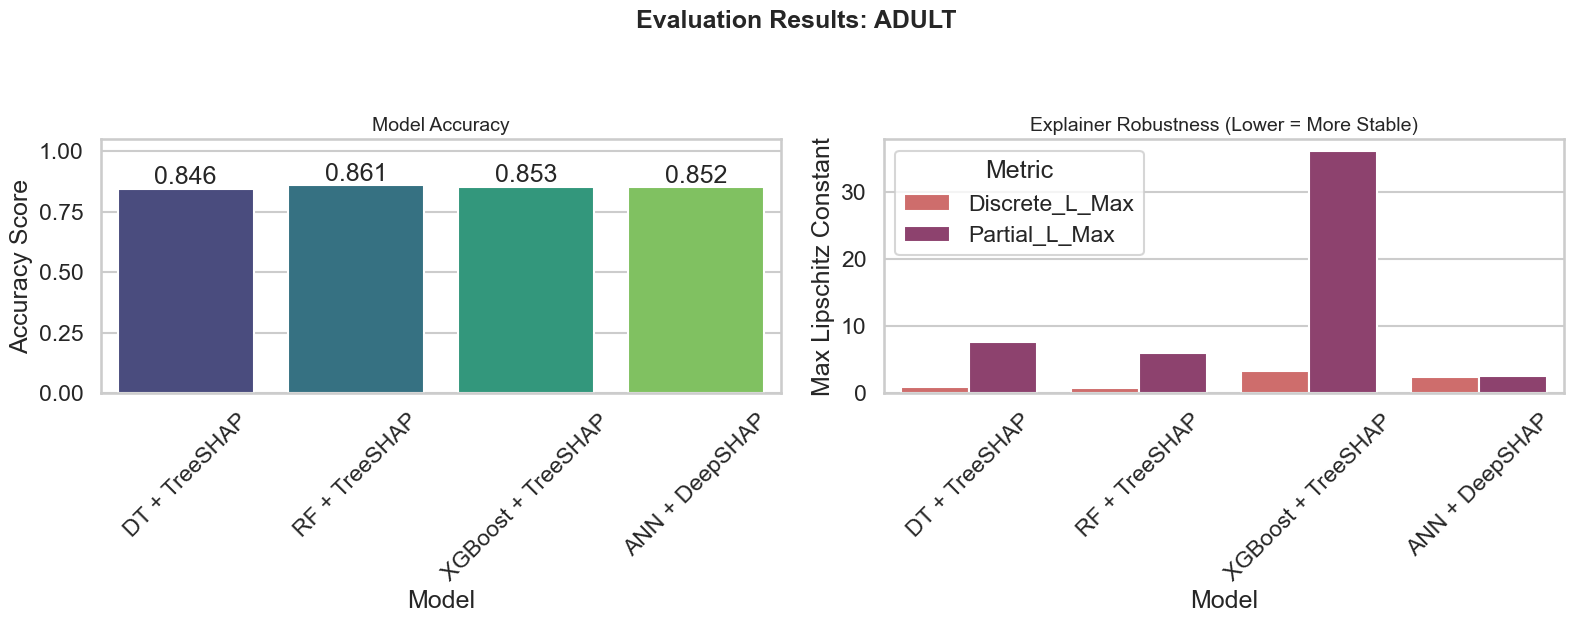


Loading GERMAN dataset (OpenML ID: 31)...
Starting Rigorous Hyperparameter Tuning...
  -> Tuning Decision Tree...
  -> Tuning Random Forest...
  -> Tuning XGBoost...
  -> Tuning Standard ANN with Early Stopping...
Initializing Native Explainers on Tuned Models...

TUNED MODEL          | ACCURACY | DISCRETE L (Jaakkola)  | PARTIAL L (Yours)   
DT + TreeSHAP        | 0.6600   | 0.0000                 | 5.1723              
RF + TreeSHAP        | 0.7650   | 0.0000                 | 0.3799              
XGBoost + TreeSHAP   | 0.7500   | 0.0000                 | 5.4680              
ANN + DeepSHAP       | 0.7450   | 0.0000                 | 0.3703              
Total Execution Time for GERMAN: 0.53 minutes



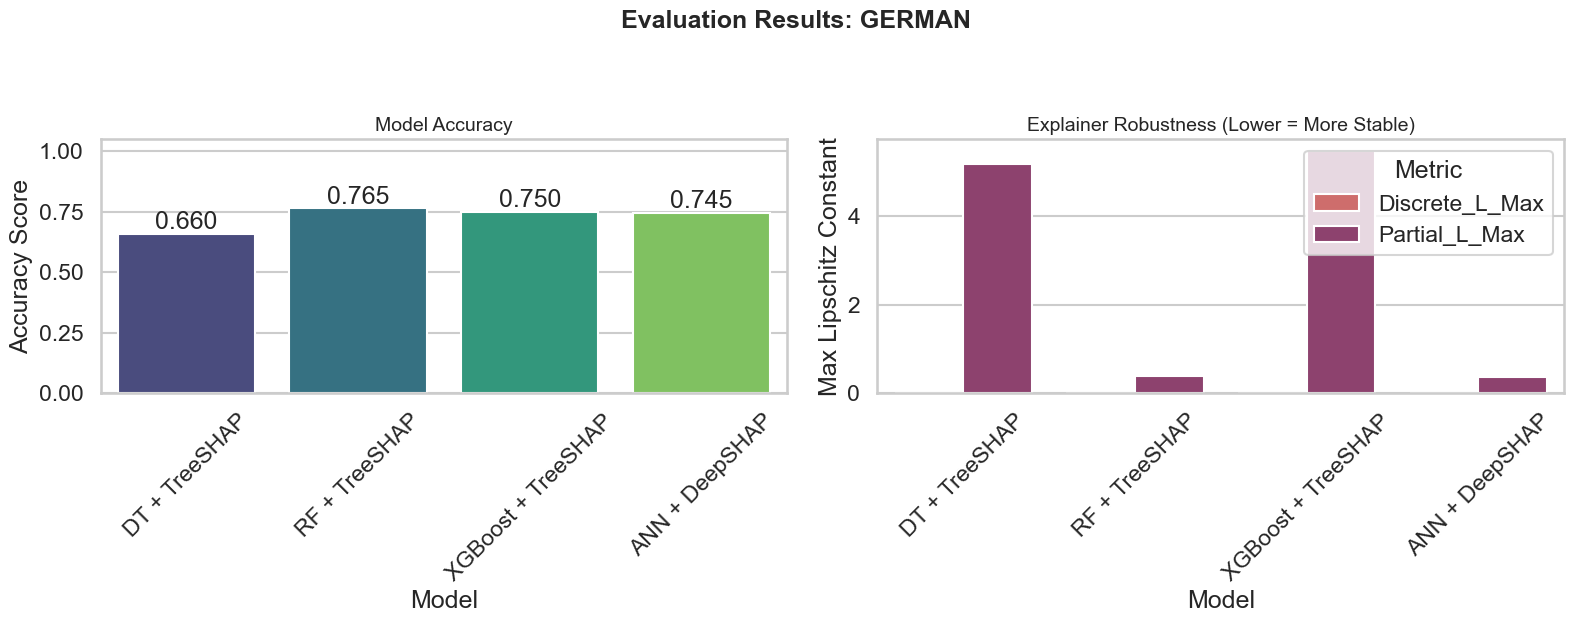

In [3]:
import numpy as np
import pandas as pd
import warnings
import time
import copy

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
import shap

# NEW IMPORTS: Matplotlib and Seaborn for stable, inline VS Code rendering
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ==========================================
# 0. EXPERIMENT HYPERPARAMETERS
# ==========================================
EPSILON_CONTINUOUS = 0.05   # Noise scale for Partial Lipschitz
EPSILON_DISCRETE = 1.5      # Distance threshold for Discrete Lipschitz
K_PERTURBATIONS = 100       # Synthetic points generated for Partial Lipschitz
N_EVAL_SAMPLES = 15         # Test instances to evaluate per dataset (keep low for speed)
CV_FOLDS = 3                # Folds for GridSearchCV

# ==========================================
# 1. DATA PREPROCESSING (Auto-Detect Features)
# ==========================================
def load_and_preprocess_data(dataset_name):             
    """
    Loads famous OpenML datasets. Automatically detects continuous vs categorical
    features, drops missing values, and strictly prevents data leakage.
    """
    openml_ids = {
        "taiwan": 42477,
        "compas": 44162,
        "adult": 1590,    # Classic census income dataset
        "german": 31      # Classic credit risk dataset
    }
    
    if dataset_name not in openml_ids:
        raise ValueError(f"Dataset {dataset_name} not supported.")
        
    print(f"\nLoading {dataset_name.upper()} dataset (OpenML ID: {openml_ids[dataset_name]})...")
    dataset = fetch_openml(data_id=openml_ids[dataset_name], as_frame=True, parser='auto')
    df = dataset.frame
    target_col = dataset.target_names[0]
    
    # Drop missing values to ensure clean processing
    df = df.dropna()

    # Separate X and y
    X_raw = df.drop(columns=[target_col])
    # Encode target to binary (0/1) reliably
    y = pd.factorize(df[target_col])[0] if df[target_col].dtype in ['category', 'object'] else df[target_col].astype(int).values

    # Auto-detect feature types based on pandas dtypes
    continuous_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X_raw.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()
    
    # Reorder X so continuous columns come first (helps with Lipschitz indexing later)
    X = X_raw[continuous_cols + categorical_cols]

    # Split data FIRST to prevent data leakage
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

    # Fit on training data ONLY, then transform both
    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)
    
    # Calculate std deviations of scaled continuous features for Partial Lipschitz noise scaling
    continuous_indices = list(range(len(continuous_cols)))
    feature_stds = X_train[:, continuous_indices].std(axis=0) if len(continuous_indices) > 0 else []
    
    return X_train, X_test, y_train, y_test, continuous_indices, feature_stds

# ==========================================
# 2. TUNING ALGORITHMS
# ==========================================
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

def tune_tree_models(X_train, y_train):
    print("  -> Tuning Decision Tree...")
    dt_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10]}
    dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_grid, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
    dt.fit(X_train, y_train)

    print("  -> Tuning Random Forest...")
    rf_grid = {'n_estimators': [50, 100], 'max_depth': [10, None], 'min_samples_leaf': [1, 2]}
    rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_grid, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
    rf.fit(X_train, y_train)

    print("  -> Tuning XGBoost...")
    xgb_grid = {'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.2]}
    xgb_m = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), xgb_grid, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
    xgb_m.fit(X_train, y_train)
    
    return dt.best_estimator_, rf.best_estimator_, xgb_m.best_estimator_

class DynamicANN(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_d, h), nn.ReLU()])
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def tune_ann(X_train, y_train, input_dim):
    print("  -> Tuning Standard ANN with Early Stopping...")
    X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    X_t_tensor, y_t_tensor = torch.tensor(X_t, dtype=torch.float32), torch.tensor(y_t, dtype=torch.float32).unsqueeze(1)
    X_v_tensor, y_v_tensor = torch.tensor(X_v, dtype=torch.float32), torch.tensor(y_v, dtype=torch.float32).unsqueeze(1)
    
    param_grid = [{'hidden': [64, 32], 'lr': 0.01}, {'hidden': [32, 16], 'lr': 0.01}]
    overall_best_loss = float('inf')
    best_params, best_optimal_epochs = None, 0
    criterion = nn.BCEWithLogitsLoss()
    
    for params in param_grid:
        model = DynamicANN(input_dim, params['hidden'])
        optimizer = optim.Adam(model.parameters(), lr=params['lr'])
        best_val_loss, epochs_no_improve, optimal_epoch = float('inf'), 0, 0
        
        for epoch in range(50):
            model.train()
            optimizer.zero_grad()
            loss = criterion(model(X_t_tensor), y_t_tensor)
            loss.backward()
            optimizer.step()
            
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_v_tensor), y_v_tensor).item()
                
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                optimal_epoch = epoch + 1
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if epochs_no_improve == 5: break
                
        if best_val_loss < overall_best_loss:
            overall_best_loss = best_val_loss
            best_params = params
            best_optimal_epochs = optimal_epoch
            
    best_model = DynamicANN(input_dim, best_params['hidden'])
    optimizer = optim.Adam(best_model.parameters(), lr=best_params['lr'])
    X_full, y_full = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    
    best_model.train()
    for _ in range(best_optimal_epochs):
        optimizer.zero_grad()
        loss = criterion(best_model(X_full), y_full)
        loss.backward()
        optimizer.step()
        
    best_model.eval()
    return best_model

# ==========================================
# 3. LIPSCHITZ MATHEMATICS
# ==========================================
def calculate_discrete_lipschitz(x_inst, X_test_pool, exp_x, explainer_fn, eps_d):
    distances = np.linalg.norm(X_test_pool - x_inst, axis=1)
    neighbors = np.where((distances > 1e-9) & (distances <= eps_d))[0]
    if len(neighbors) == 0: return np.nan
    
    dist_x = distances[neighbors]
    dist_exp = np.linalg.norm(explainer_fn(X_test_pool[neighbors]) - exp_x, axis=1)
    return np.max(dist_exp / dist_x)

def calculate_partial_lipschitz(x_inst, exp_x, explainer_fn, cont_idx, feat_stds, eps_c, k):
    if len(cont_idx) == 0: return np.nan # Failsafe if no continuous features exist
    x_pert = np.tile(x_inst, (k, 1)).astype(float)
    for i, idx in enumerate(cont_idx):
        x_pert[:, idx] += np.random.normal(0, eps_c * feat_stds[i], k)
        
    dist_x = np.linalg.norm(x_pert - x_inst, axis=1) + 1e-9
    dist_exp = np.linalg.norm(explainer_fn(x_pert) - exp_x, axis=1)
    return np.max(dist_exp / dist_x)

# ==========================================
# 4. STATIC INLINE VISUALIZATIONS
# ==========================================
def create_static_plots(results_df, dataset_name):
    """
    Generates Matplotlib/Seaborn plots that render directly inside VS Code cells
    without requiring external browser tabs.
    """
    sns.set_theme(style="whitegrid", context="talk")
    
    # Create a 1x2 subplot grid
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Evaluation Results: {dataset_name.upper()}", fontsize=18, fontweight='bold', y=1.05)
    
    # Plot 1: Accuracy Comparison
    sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[0], palette="viridis")
    axes[0].set_title("Model Accuracy", fontsize=14)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Accuracy Score")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Annotate bars with values
    for p in axes[0].patches:
        axes[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points')

    # Plot 2: Lipschitz Robustness (Grouped Bar Chart)
    # Melt dataframe for seaborn 'hue' grouping
    df_melted = results_df.melt(id_vars=['Model'], value_vars=['Discrete_L_Max', 'Partial_L_Max'], 
                                var_name='Metric', value_name='Lipschitz_Value')
    
    sns.barplot(data=df_melted, x='Model', y='Lipschitz_Value', hue='Metric', ax=axes[1], palette="flare")
    axes[1].set_title("Explainer Robustness (Lower = More Stable)", fontsize=14)
    axes[1].set_ylabel("Max Lipschitz Constant")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show() # This triggers the inline render in VS Code

# ==========================================
# 5. MASTER EVALUATION LOOP
# ==========================================
def run_metric_comparison(dataset_name):
    t0 = time.time()
    X_train, X_test, y_train, y_test, cont_indices, feat_stds = load_and_preprocess_data(dataset_name)
    input_dim = X_train.shape[1]
    
    print("Starting Rigorous Hyperparameter Tuning...")
    dt, rf, xgb_m = tune_tree_models(X_train, y_train)
    ann = tune_ann(X_train, y_train, input_dim)

    print("Initializing Native Explainers on Tuned Models...")
    tree_exp_dt = shap.TreeExplainer(dt)
    tree_exp_rf = shap.TreeExplainer(rf)
    tree_exp_xgb = shap.TreeExplainer(xgb_m)
    
    background_data = torch.tensor(shap.sample(X_train, 100, random_state=42), dtype=torch.float32)
    deep_exp_ann = shap.DeepExplainer(ann, background_data)
    
    def shape_fix(sv): 
        if isinstance(sv, list): return np.array(sv[-1])
        if len(sv.shape) == 3: return sv[:, :, -1]
        return sv

    wrappers = {
        "DT + TreeSHAP": lambda X: shape_fix(tree_exp_dt.shap_values(X)),
        "RF + TreeSHAP": lambda X: shape_fix(tree_exp_rf.shap_values(X)),
        "XGBoost + TreeSHAP": lambda X: shape_fix(tree_exp_xgb.shap_values(X)),
        "ANN + DeepSHAP": lambda X: shape_fix(deep_exp_ann.shap_values(torch.tensor(X, dtype=torch.float32)))
    }

    np.random.seed(42)
    eval_indices = np.random.choice(len(X_test), N_EVAL_SAMPLES, replace=False)
    
    print("\n" + "="*85)
    print(f"{'TUNED MODEL':<20} | {'ACCURACY':<8} | {'DISCRETE L (Jaakkola)':<22} | {'PARTIAL L (Yours)':<20}")
    print("="*85)

    results_list = []

    for name, wrapper in wrappers.items():
        base_name = name.split(" ")[0]
        
        if base_name == "ANN": 
            preds = (torch.sigmoid(ann(torch.tensor(X_test, dtype=torch.float32))).detach().numpy().squeeze() >= 0.5).astype(int)
        elif base_name == "XGBoost": preds = xgb_m.predict(X_test)
        elif base_name == "RF": preds = rf.predict(X_test)
        else: preds = dt.predict(X_test)
        
        acc = accuracy_score(y_test, preds)
        
        disc_scores, part_scores = [], []
        for idx in eval_indices:
            x_inst = X_test[idx:idx+1]
            exp_base = wrapper(x_inst)
            
            l_disc = calculate_discrete_lipschitz(x_inst, X_test, exp_base, wrapper, EPSILON_DISCRETE)
            l_part = calculate_partial_lipschitz(x_inst, exp_base, wrapper, cont_indices, feat_stds, EPSILON_CONTINUOUS, K_PERTURBATIONS)
            
            if not np.isnan(l_disc): disc_scores.append(l_disc)
            if not np.isnan(l_part): part_scores.append(l_part)
            
        max_disc = np.max(disc_scores) if disc_scores else 0
        max_part = np.max(part_scores) if part_scores else 0
        
        print(f"{name:<20} | {acc:.4f}   | {max_disc:<22.4f} | {max_part:<20.4f}")
        
        results_list.append({
            'Model': name,
            'Accuracy': acc,
            'Discrete_L_Max': max_disc,
            'Partial_L_Max': max_part
        })
    
    print("="*85)
    print(f"Total Execution Time for {dataset_name.upper()}: {(time.time() - t0)/60:.2f} minutes\n")
    
    # Create DataFrame and plot natively inside VS Code
    results_df = pd.DataFrame(results_list)
    create_static_plots(results_df, dataset_name)

if __name__ == "__main__":
    # Running the core datasets plus the newly added classic datasets
    datasets_to_run = ["taiwan", "compas", "adult", "german"]
    
    print(f"Starting evaluation across {len(datasets_to_run)} datasets. This may take some time...")
    for ds in datasets_to_run:
        run_metric_comparison(ds)